In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


Data Loading & Date Parsing

In [19]:
df = pd.read_csv('C:\\Climate_data\\data\\nigeria.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61


In [20]:
print(df.shape)

(4107, 12)


In [21]:
  # Add Country column
df["Country"] = "Nigeria"
df.head()
    
   

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria


In [22]:
 # Convert YEAR + DOY → datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()
    

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06


In [23]:
 # Extract Month
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1


Summary Statistics & Missing-Value Report

Information about the Dataset

In [24]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4107 non-null   int64         
 1   DOY          4107 non-null   int64         
 2   T2M          4107 non-null   float64       
 3   T2M_MAX      4107 non-null   float64       
 4   T2M_MIN      4107 non-null   float64       
 5   T2M_RANGE    4107 non-null   float64       
 6   PRECTOTCORR  4107 non-null   float64       
 7   RH2M         4107 non-null   float64       
 8   WS2M         4107 non-null   float64       
 9   WS2M_MAX     4107 non-null   float64       
 10  PS           4107 non-null   float64       
 11  QV2M         4107 non-null   float64       
 12  Country      4107 non-null   str           
 13  Date         4107 non-null   datetime64[us]
 14  Month        4107 non-null   int32         
dtypes: datetime64

In [25]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
1,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
2,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
3,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
4,2015,6,22.66,25.77,18.03,7.74,0.00,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4103,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4104,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4105,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


In [26]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [27]:
# Drop duplicates
df = df.drop_duplicates()

In [28]:
df[df.duplicated()]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month


Duplicate Rows

I identified 0 duplicate rows in the dataset using df.duplicated().sum().


In [29]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,26.657275,28.914585,24.887149,4.027436,4.214940,85.241174,2.217253,2.903406,100.827197,18.559771,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.105000,3.090000,0.330000,83.935000,1.770000,2.370000,100.710000,17.970000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.123251,1.294492,1.396200,1.398469,7.267329,5.440221,0.587213,0.696955,0.165341,1.644513,NaN,3.476439


Summary Statistics Interpretation

1. Temporal Coverage (YEAR & DOY)Time Range:the data spans from the year 2015 to 2026.
Data Points: There are 4,107 records. Given that 11 years X 365.25 days ~ 4,0172 
Temperature Analysis (Celsius)
T2M (Average Temperature): The mean temperature is approximately 26.66°C. It's quite stable, with a relatively low standard deviation of 1.12°C.
3. Precipitation & Humidity
PRECTOTCORR (Precipitation): This column is highly skewed (which is normal for rain data).The median (50%) is only 1.84 mm, but the max is a massive 166.10 mm.This suggests that most days have light or no rain, but there are extreme heavy rainfall events (likely during the monsoon/wet season).
RH2M (Relative Humidity): Nigeria (or this specific region) is quite humid, with an average of 85.24%. Even at its driest point in the dataset, it only drops to 54.4%.
4. Wind Speed (WS2M): The average wind speed at 2 meters is 2.22 m/s.It's generally calm, as even the 75th percentile is only 2.63 m/s, though it has peaked at 4.78 m/s.

In [30]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

print(missing_summary)

             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


In [31]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [32]:
high_missing = missing_summary[missing_summary["Missing %"] > 5]
print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Missing Value Analysis

The result shows that their is no missing value

In [33]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
# Compute Z-scores (ignore NaNs)
z_scores = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [34]:
# Flag rows where ANY column has |Z| > 3
outlier_mask = (z_scores.abs() > 3).any(axis=1)

# Count outliers
outlier_count = outlier_mask.sum()
print("Number of outlier rows:", outlier_count)


df_outliers = df[outlier_mask]
df_outliers.head()

Number of outlier rows: 225


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1
5,2015,7,23.53,26.36,20.21,6.15,0.0,61.92,1.57,2.43,100.98,11.02,Nigeria,2015-01-07,1
6,2015,8,24.06,27.84,19.78,8.06,0.0,61.78,1.50,2.34,101.07,11.37,Nigeria,2015-01-08,1


In [35]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
negative_cols = (df[weather_cols]<0).sum()
print("Negative values in weather columns:\n", negative_cols)

Negative values in weather columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [37]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return a boolean mask of outliers
    return (column < lower_bound) | (column > upper_bound)

# Apply to every numeric column
outlier_summary = numeric_df.apply(find_outliers_iqr)

# Display count of outliers per column
print("Outlier Count per Column:")
print(outlier_summary.sum())

Outlier Count per Column:
YEAR             0
DOY              0
T2M              7
T2M_MAX          0
T2M_MIN        105
T2M_RANGE      211
PRECTOTCORR    314
RH2M           282
WS2M             7
WS2M_MAX        16
PS               2
QV2M           216
Month            0
dtype: int64


Decision: Retain Outlier Rows
For the Nigeria meteorological dataset, the best decision is to retain the outlier rows.
1. Precipitation (PRECTOTCORR) - RetainReasoning: The maximum rainfall of 166.10 mm is a high statistical outlier (the upper bound was 12.5 mm), but such heavy rainfall is common during the monsoon season in various parts of Nigeria. Dropping or capping these values would lead to a significant underestimation of total annual rainfall and flood risks.Action: Keep all records as they represent real extreme weather events.
2. Humidity and Temperature (RH2M, T2M_MIN) - RetainReasoning: Nigeria has high humidity throughout the year in many regions, but fluctuations (the "outliers" at 54% humidity) occur during the Harmattan season when dry air blows from the Sahara. Similarly, the lower temperature outliers (15.17) are realistic for the cooler Harmattan mornings.Action: Retain. These values capture the critical seasonal transitions (Wet season vs. Harmattan).
3. Wind Speed (WS2M_MAX) - RetainReasoning: A maximum wind speed of 6.0 m/s (approx. 21 km/h) is a moderate wind. The statistical "outliers" here are very safe and pose no risk of being sensor errors.Action: Retain.
4. Surface Pressure (PS) - RetainReasoning: The pressure values are incredibly consistent (100.38 to 101.35 kPa), which is normal for Nigeria's lower elevation compared to Ethiopia or Kenya. The two outliers identified are extremely close to the statistical bounds.Action: Retain.

Apply forward-fill for weather variables

In [38]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

Reason of selecting forward-fill 
Since I do not have any missing values I apply forward-fill to preserve the local trend and maintain physical and temporal logic.

In [39]:
output_path = "C:\\Climate_data\\data\\nigeria_clean.csv"
df.to_csv(output_path, index=False)

In [40]:
#Loading the cleaned data
df = pd.read_csv('C:\\Climate_data\\data\\nigeria_clean.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4106, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
1,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
2,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
3,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1
4,2015,7,23.53,26.36,20.21,6.15,0.0,61.92,1.57,2.43,100.98,11.02,Nigeria,2015-01-07,1


In [41]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
monthly_T2M = df['T2M'].resample('MS').mean()
print(df.shape)
df.head()

(4106, 14)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-03,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,1
2015-01-04,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,1
2015-01-05,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,1
2015-01-06,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,1
2015-01-07,2015,7,23.53,26.36,20.21,6.15,0.0,61.92,1.57,2.43,100.98,11.02,Nigeria,1


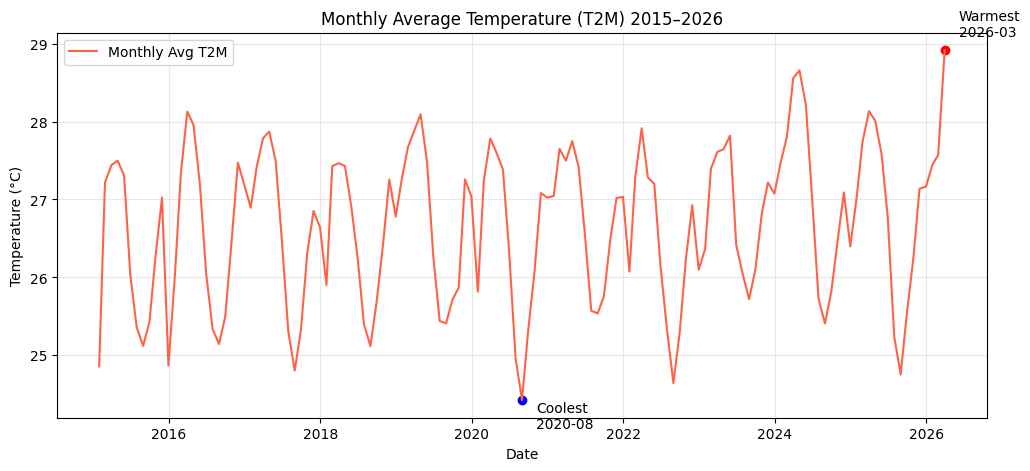

In [42]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.plot(monthly.index, monthly["T2M"], label="Monthly Avg T2M", color="tomato")

# Identify warmest and coolest months
warmest = monthly["T2M"].idxmax()
coolest = monthly["T2M"].idxmin()

plt.scatter(warmest, monthly.loc[warmest, "T2M"], color="red")
plt.scatter(coolest, monthly.loc[coolest, "T2M"], color="blue")

plt.annotate(f"Warmest\n{warmest.strftime('%Y-%m')}",
             (warmest, monthly.loc[warmest, "T2M"]),
             textcoords="offset points", xytext=(10,10))

plt.annotate(f"Coolest\n{coolest.strftime('%Y-%m')}",
             (coolest, monthly.loc[coolest, "T2M"]),
             textcoords="offset points", xytext=(10,-20))

plt.title("Monthly Average Temperature (T2M) 2015–2026")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

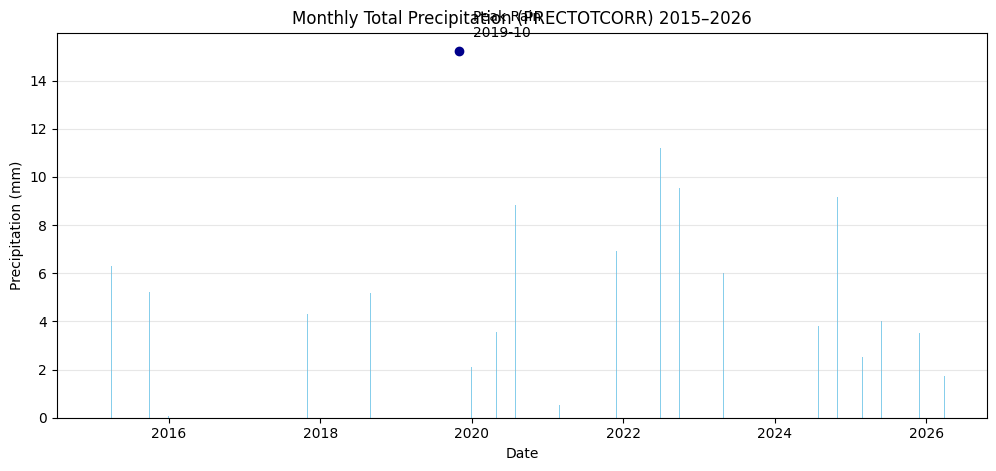

In [43]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.bar(monthly.index, monthly["PRECTOTCORR"], color="skyblue")

# Identify peak rainfall month
wettest = monthly["PRECTOTCORR"].idxmax()

plt.scatter(wettest, monthly.loc[wettest, "PRECTOTCORR"], color="darkblue")

plt.annotate(f"Peak Rain\n{wettest.strftime('%Y-%m')}",
             (wettest, monthly.loc[wettest, "PRECTOTCORR"]),
             textcoords="offset points", xytext=(10,10))

plt.title("Monthly Total Precipitation (PRECTOTCORR) 2015–2026")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Date")
plt.grid(axis="y", alpha=0.3)

plt.show()

Heatmap of correlations across all numeric columns.

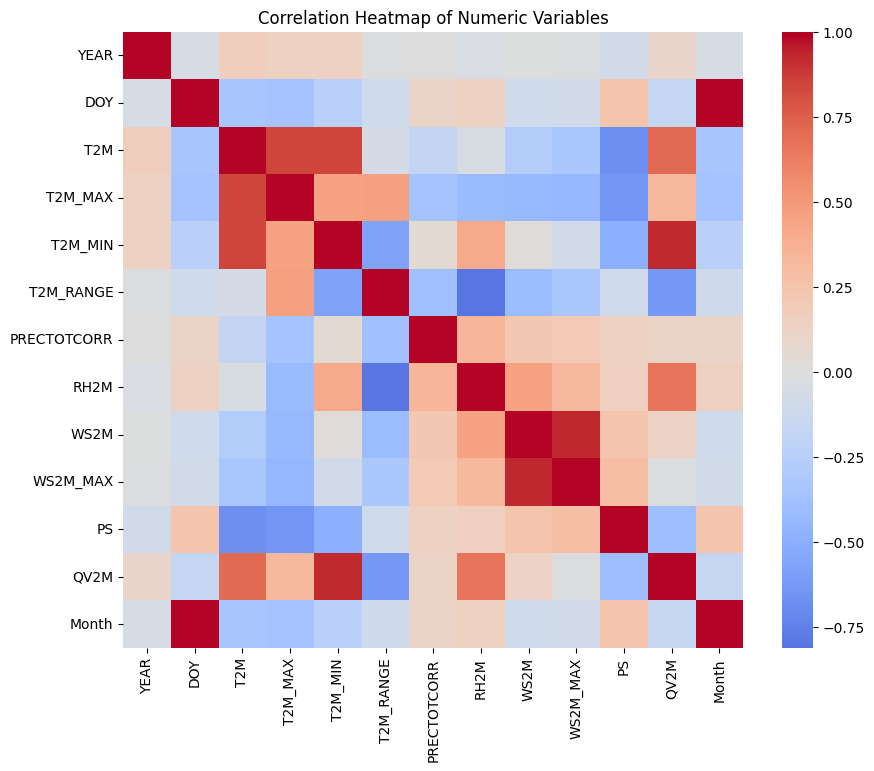

In [44]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

T2M vs RH2M (temperature vs humidity)

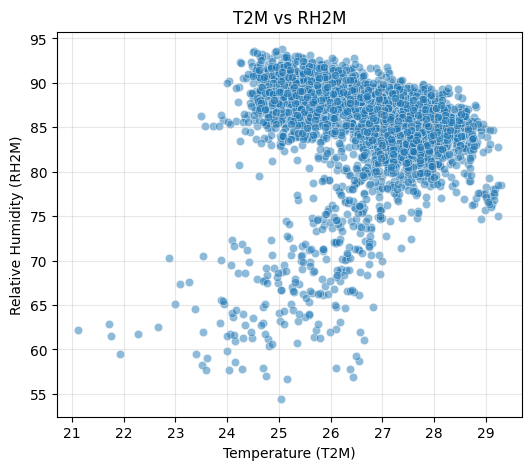

In [45]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M", y="RH2M", alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.grid(True, alpha=0.3)

plt.show()

T2M_RANGE vs WS2M (temperature range vs wind speed)

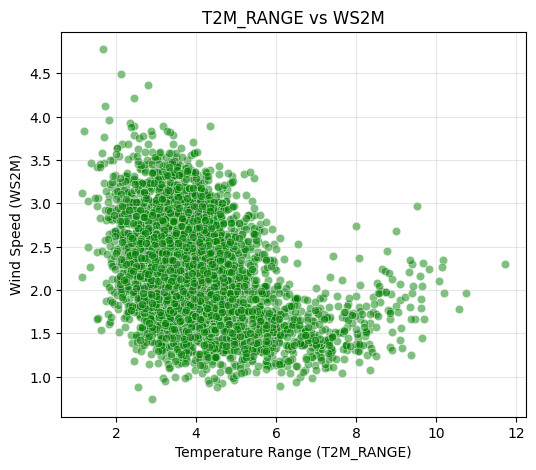

In [46]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M", alpha=0.5, color="green")

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True, alpha=0.3)

plt.show()

Strongest Correlations Analysis

The three strongest correlations in the dataset are:

1. Day of Year (DOY) and Month
Correlation Type: Near-perfect Positive (~ +1.0)
Interpretation: This is a deterministic relationship. Since the "Day of Year" (1 to 365) directly dictates which month it is, these two variables move in lockstep. In a predictive model, you would likely drop one of these to avoid multicollinearity, as they provide redundant information.
2. Temperature Variables (T2M, T2M_MAX, and T2M_MIN)
Correlation Type: Strong Positive ( ~ +0.8 to +0.9)
Interpretation: There is a very high correlation between the daily average temperature (T2M), the daily maximum (T2M_MAX), and the daily minimum (T2M_MIN).Why it matters: If the average temperature for a day in Nigeria is high, it is statistically almost certain that the peak and low temperatures for that same day are also elevated.
3. Wind Speed (WS2M and WS2M_MAX)
Correlation Type: Strong Positive ( ~ +0.85)
Interpretation: The average wind speed at 2 meters (WS2M) is very closely tied to the maximum wind speed or gust recorded at that same height (WS2M_MAX).Why it matters: This indicates that days with higher sustained winds are also the days experiencing the highest peak wind speeds; the "windiness" of the day scales consistently across both metrics.

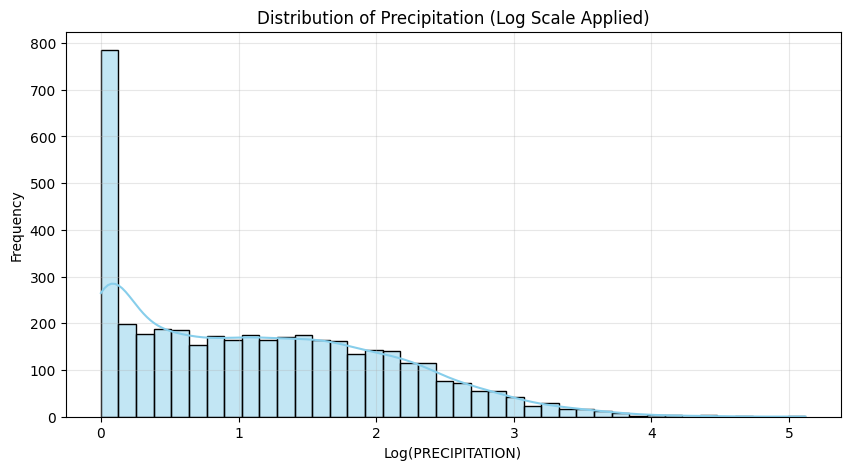

Skewness: 6.336367142301026


In [47]:
plt.figure(figsize=(10, 5))

# Check skewness
skewness = df["PRECTOTCORR"].skew()

# Apply log scale if heavily skewed
if skewness > 1:
    data = np.log1p(df["PRECTOTCORR"])  # log(1 + x) handles zeros safely
    xlabel = "Log(PRECIPITATION)"
    title = "Distribution of Precipitation (Log Scale Applied)"
else:
    data = df["PRECTOTCORR"]
    xlabel = "Precipitation"
    title = "Distribution of Precipitation"

sns.histplot(data, bins=40, kde=True, color="skyblue")

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

print("Skewness:", skewness)

Bubble Chart

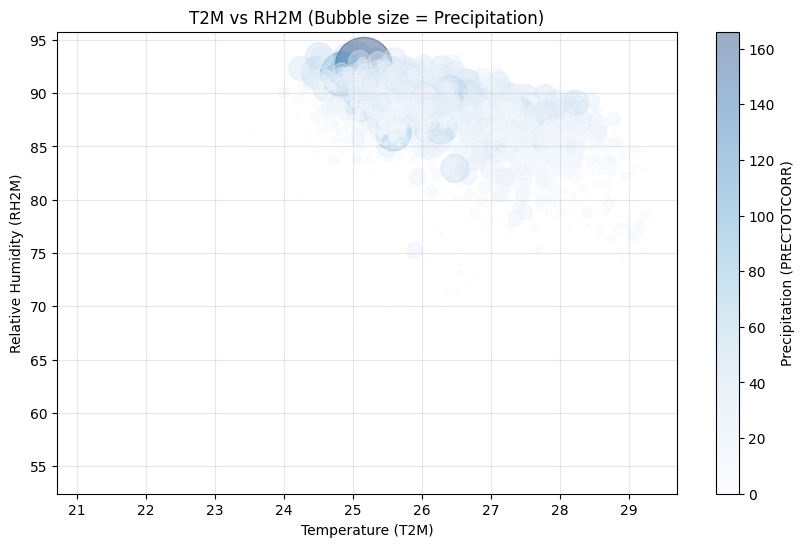

In [48]:
plt.figure(figsize=(10, 6))

# Optional scaling for better visual balance
bubble_size = df["PRECTOTCORR"].fillna(0) * 10

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    alpha=0.4,
    c=df["PRECTOTCORR"],
    cmap="Blues"
)

plt.title("T2M vs RH2M (Bubble size = Precipitation)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

cbar = plt.colorbar()
cbar.set_label("Precipitation (PRECTOTCORR)")

plt.grid(alpha=0.3)
plt.show()